<a href="https://colab.research.google.com/github/lovita11/DataScience/blob/main/Pertemuan11_LovitaPrasetiaLestari_250401020061.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Nama : Lovita Prasetia lestari

NIM : 250401020061

Kelas : IF403

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =======================================================================
# Langkah 1: Generate dataset sintetis pelanggan (3 kelompok tersembunyi)
# =======================================================================

np.random.seed(42)

grp1 = np.random.normal([30, 20], [6, 8], (100, 2))   # hemat
grp2 = np.random.normal([70, 55], [8, 10], (100, 2))  # menengah
grp3 = np.random.normal([110, 85], [10, 8], (100, 2)) # boros

data = np.vstack([grp1, grp2, grp3])

df = pd.DataFrame(
    data,
    columns=['pendapatan_tahunan', 'skor_belanja']
)

df['usia'] = np.random.randint(18, 65, len(df))
df['gender'] = np.random.choice(['L', 'P'], len(df))

print("Shape:", df.shape)
print(df.describe().round(2))

df.head()

Shape: (300, 4)
       pendapatan_tahunan  skor_belanja    usia
count              300.00        300.00  300.00
mean                69.96         53.23   42.07
std                 33.82         27.41   13.59
min                 14.28          4.10   18.00
25%                 32.14         25.60   30.00
50%                 70.84         55.11   43.00
75%                103.40         78.16   53.00
max                140.79        103.17   64.00


,pendapatan_tahunan,skor_belanja,usia,gender
0,32.980285,18.893886,64,P
1,33.886131,32.184239,21,P
2,28.595080,18.126904,29,L
3,39.475277,26.139478,62,L
4,27.183154,24.340480,19,L


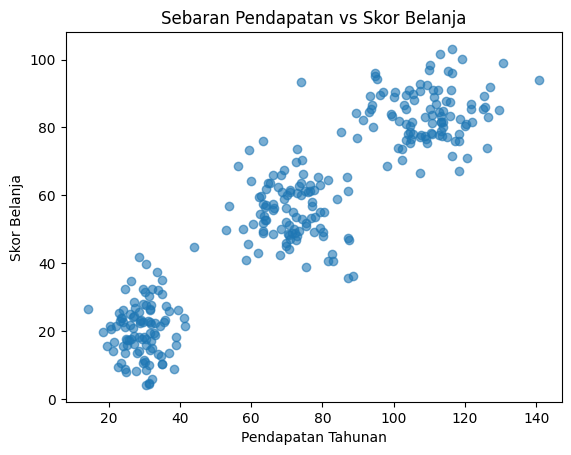

In [ ]:
plt.scatter(
    df['pendapatan_tahunan'],
    df['skor_belanja'],
    alpha=0.6
)

plt.xlabel('Pendapatan Tahunan')
plt.ylabel('Skor Belanja')
plt.title('Sebaran Pendapatan vs Skor Belanja')
plt.show()

In [7]:
# ==========================================
# Langkah 2: Preprocessing Data
# ==========================================

from sklearn.preprocessing import StandardScaler

# Memilih fitur numerik untuk clustering
X = df[['pendapatan_tahunan', 'skor_belanja']].values

# Standardisasi data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Rata-rata setelah scaling:",
      X_scaled.mean(axis=0).round(3))

print("Std setelah scaling:",
      X_scaled.std(axis=0).round(3))

print("\nKeterangan:")
print("Data pendapatan tahunan dan skor belanja berhasil distandardisasi.")
print("Hasil scaling memiliki rata-rata mendekati 0 dan standar deviasi 1.")

Rata-rata setelah scaling: [-0.  0.]
Std setelah scaling: [1. 1.]

Keterangan:
Data pendapatan tahunan dan skor belanja berhasil distandardisasi.
Hasil scaling memiliki rata-rata mendekati 0 dan standar deviasi 1.


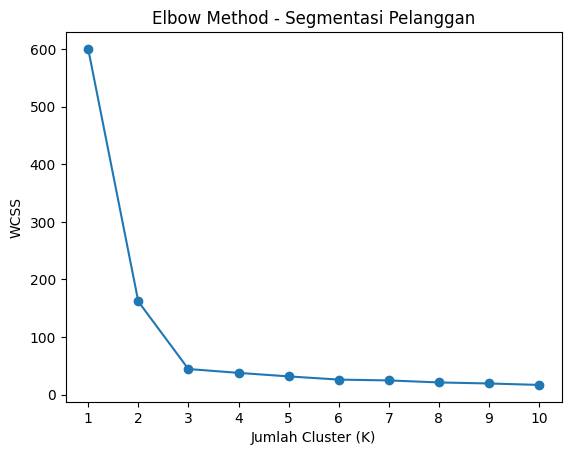

In [ ]:
# ==========================================
# Langkah 3: Metode Elbow untuk Menentukan K
# ==========================================

from sklearn.cluster import KMeans

wcss = []

for k in range(1, 11):
    km = KMeans(
        n_clusters=k,
        random_state=42,
        n_init='auto'
    )

    km.fit(X_scaled)
    wcss.append(km.inertia_)

# Visualisasi Elbow Method
plt.plot(range(1, 11), wcss, marker='o')
plt.xlabel('Jumlah Cluster (K)')
plt.ylabel('WCSS')
plt.title('Elbow Method - Segmentasi Pelanggan')
plt.xticks(range(1, 11))
plt.show()

### Interpretasi Elbow Method

Berdasarkan grafik Elbow Method, penurunan nilai WCSS terlihat cukup tajam hingga K = 3 dan setelah itu kurva mulai melandai. Oleh karena itu, jumlah cluster optimal yang dipilih adalah **K = 3**.

Hasil ini sesuai dengan karakteristik dataset sintetis yang dibuat, yaitu memiliki tiga kelompok pelanggan tersembunyi: kelompok hemat, menengah, dan boros.

In [ ]:
# ==========================================
# Langkah 4: Melatih Model K-Means
# ==========================================

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Membuat model K-Means dengan K optimal = 3
model = KMeans(
    n_clusters=3,
    random_state=42,
    n_init='auto'
)
# Melatih Model
model.fit(X_scaled)

# Menambahkan hasil cluster ke dataframe
df['cluster'] = model.labels_

# Menampilkan hasil evaluasi
print("WCSS akhir       :", round(model.inertia_, 3))
print("Silhouette Score :", round(silhouette_score(X_scaled, model.labels_), 3))

# Menampilkan rata-rata karakteristik setiap cluster
print("\nRata-rata setiap cluster:")
print(
    df.groupby('cluster')[
        ['pendapatan_tahunan', 'skor_belanja']
    ].mean().round(2)
)

WCSS akhir       : 44.556
Silhouette Score : 0.695

Rata-rata setiap cluster:
         pendapatan_tahunan  skor_belanja
cluster                                  
0                     70.99         55.05
1                     29.31         20.27
2                    109.20         84.08


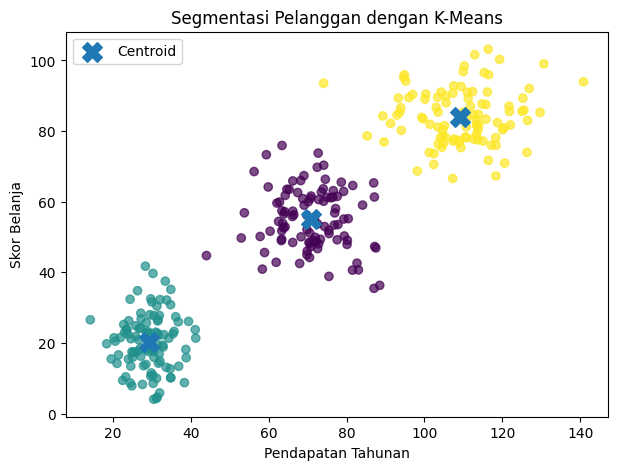

In [ ]:
# ==========================================
# Langkah 5: Visualisasi Hasil Clustering
# ==========================================

# Mengubah posisi centroid dari data hasil scaling
# kembali ke skala asli agar mudah dibaca
centroids = scaler.inverse_transform(model.cluster_centers_)

# Membuat scatter plot hasil clustering
plt.figure(figsize=(7, 5))

plt.scatter(
    df['pendapatan_tahunan'],
    df['skor_belanja'],
    c=df['cluster'],
    alpha=0.7
)

# Menampilkan centroid
plt.scatter(
    centroids[:, 0],
    centroids[:, 1],
    marker='X',
    s=200,
    label='Centroid'
)

plt.xlabel('Pendapatan Tahunan')
plt.ylabel('Skor Belanja')
plt.title('Segmentasi Pelanggan dengan K-Means')
plt.legend()
plt.show()

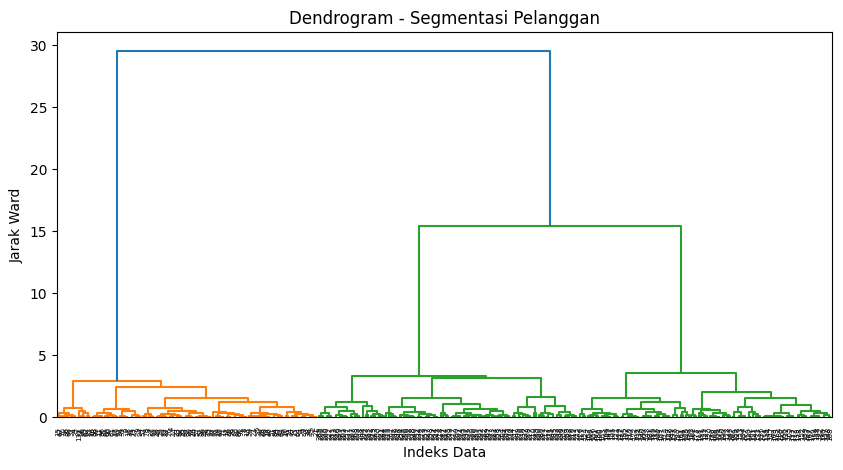

In [ ]:
# ==========================================
# Langkah 6: Hierarchical Clustering
# ==========================================

from scipy.cluster.hierarchy import dendrogram, linkage

# Membuat linkage menggunakan metode Ward
Z = linkage(X_scaled, method='ward')

# Menampilkan dendrogram
plt.figure(figsize=(10, 5))

dendrogram(Z)

plt.title('Dendrogram - Segmentasi Pelanggan')
plt.xlabel('Indeks Data')
plt.ylabel('Jarak Ward')
plt.show()

Kesimpulan:
Pada Pertemuan 11 dilakukan proses clustering secara end-to-end menggunakan dataset pelanggan sintetis berdasarkan pendapatan dan perilaku belanja. Elbow Method menghasilkan jumlah cluster optimal K = 3, yang kemudian dengan K-Means menghasilkan tiga segmen pelanggan, yaitu Hemat, Menengah, dan Boros. Hasil tersebut juga didukung oleh Hierarchical Clustering melalui dendrogram yang menunjukkan tiga kelompok utama.